# CALoRa Detection Rate vs SNR — Comparison Plot

Select which result CSV files to overlay on a single graph.

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import os
import glob

results_dir = os.path.join('.', 'results2')

# List all available CSV files
all_csvs = sorted(glob.glob(os.path.join(results_dir, '*.csv')))
print(f'Available result files in {results_dir}:')
for i, f in enumerate(all_csvs):
    print(f'  [{i}] {os.path.basename(f)}')

Available result files in .\results2:
  [0] calora_clean.csv
  [1] calora_clean_cfo.csv
  [2] calora_results_20260807_162213.csv
  [3] calora_results_20260807_175103.csv
  [4] calora_traincfo_testcfo.csv
  [5] calora_traincfo_testcfosean.csv
  [6] calora_traincfo_testclean.csv
  [7] conventional_results_20260806_cfo.csv
  [8] conventional_results_cfo_125.csv
  [9] conventional_results_clean_125.csv
  [10] conventional_results_clean_1m.csv


In [84]:
import csv

def format_snr_data(raw_csv_text):
    """
    Takes raw CSV text with 'snr,n,avg_prob,det_rate', 
    and returns a new string formatted as 'SNR,DetRate'.
    """
    # Split the raw text into individual lines
    lines = raw_csv_text.strip().split('\n')
    
    # Initialize the output list with the new header
    formatted_lines = ["SNR,DetRate"]
    
    # Loop through the data, skipping the original header (lines[1:])
    for line in lines[1:]:
        # Skip any empty lines
        if not line.strip():
            continue
            
        parts = line.split(',')
        if len(parts) >= 4:
            snr = parts[0].strip()
            det_rate = parts[3].strip()
            formatted_lines.append(f"{snr},{det_rate}")
            
    # Join everything back into a single multi-line string
    return '\n'.join(formatted_lines)

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  EDIT HERE: specify the files you want to compare              ║
# ║  Use the exact filenames (without path) from the list above    ║
# ╚══════════════════════════════════════════════════════════════════╝

selected_files = [
    'calora_clean.csv',
    'calora_results_20260807_162213.csv',
    'calora_traincfo_testclean.csv',
    'calora_traincfo_testcfo.csv'
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    'calora train clean, test clean (YS)',
    
    'calora train clean, test clean (Sean)',
    'calora train cfo (ys), test clean (Ys)',
    'calora train cfo (ys), test cfo (Ys)'
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ calora_clean.csv
✅ calora_results_20260807_162213.csv
✅ calora_traincfo_testclean.csv
✅ calora_traincfo_testcfo.csv


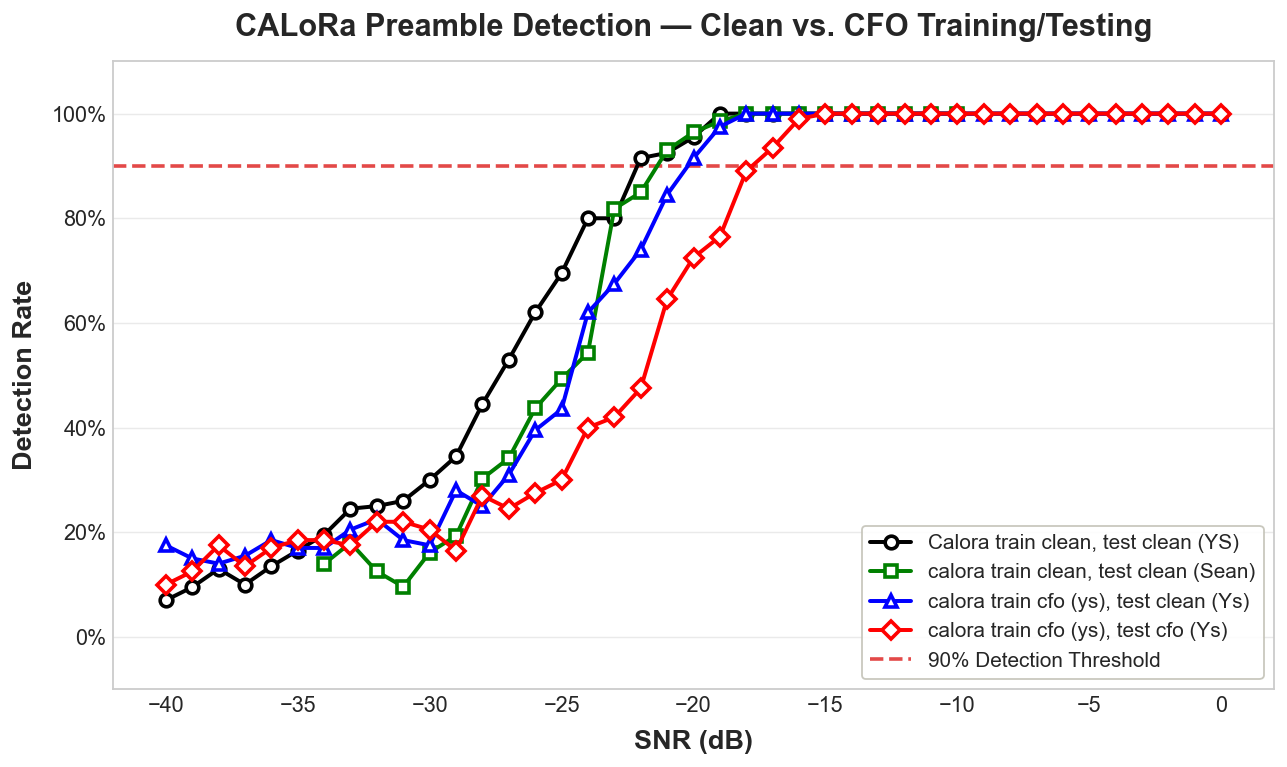


Plot saved to results2/detrate_calora_clean_vs_cfo.png


In [86]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')

# Fixed, colorblind-safe categorical palette — same slot order everywhere so a
# given series always reads the same color across every figure in this notebook.
# Red is reserved exclusively for the 90% detection-rate threshold line below.
PALETTE = ['black', 'green', 'blue', 'red', '#e87ba4', '#008300', '#4a3aa7']
THRESHOLD_COLOR = '#e34948'

fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).reset_index(drop=True)
    df = df.rename(columns={'snr': 'SNR', 'det_rate': 'DetRate'})
    if df['DetRate'].mean() > 1:
    # If yes, divide the entire column by 100 to convert it from percentages to decimals
        df['DetRate'] = df['DetRate'] / 100
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=PALETTE[i % len(PALETTE)],
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=PALETTE[i % len(PALETTE)],
        label=lbl
    )

# Reference line: 90% detection rate threshold
ax.axhline(y=0.9, color=THRESHOLD_COLOR, linestyle='--', linewidth=2, zorder=1,
           label='90% Detection Threshold')

ax.set_xlabel('SNR (dB)', fontsize=15, fontweight='bold', labelpad=8)
ax.set_ylabel('Detection Rate', fontsize=15, fontweight='bold', labelpad=8)
ax.set_title('CALoRa Preamble Detection — Clean vs. CFO Training/Testing', fontsize=17, fontweight='bold', pad=14)
ax.set_ylim(-0.1, 1.10)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=11.5, loc='lower right', frameon=True, framealpha=0.9, edgecolor='#c3c2b7')
ax.grid(True, axis='y', alpha=0.4)
ax.grid(False, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'detrate_calora_clean_vs_cfo.png'), dpi=200, bbox_inches='tight')
plt.show()
print('\nPlot saved to results2/detrate_calora_clean_vs_cfo.png')

In [87]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  EDIT HERE: specify the files you want to compare              ║
# ║  Use the exact filenames (without path) from the list above    ║
# ╚══════════════════════════════════════════════════════════════════╝

selected_files = [
    
    'calora_clean.csv',
    'conventional_results_clean_1m.csv',
    'conventional_results_clean_125.csv'
    
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    
     'Calora train clean, test clean (YS)',
     'Conventional method test clean (1 MHz)',
     'Conventional method test clean (125 kHz)',
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ calora_clean.csv
✅ conventional_results_clean_1m.csv
✅ conventional_results_clean_125.csv


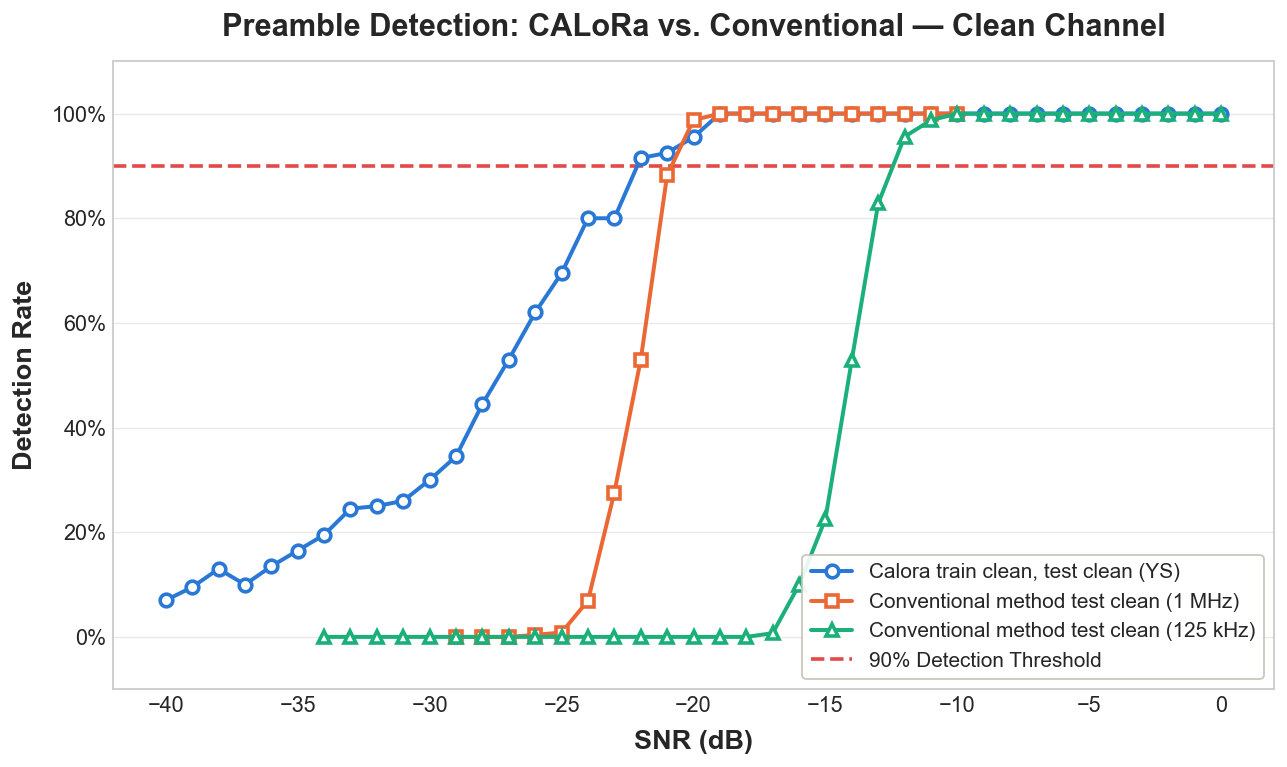


Plot saved to results2/detrate_calora_vs_conventional_clean.png


In [88]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')

# Color is assigned by series identity (not list position), so CALoRa and each
# conventional bandwidth keep the same color on every figure in this notebook.
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7']
THRESHOLD_COLOR = '#e34948'

def color_for(lbl, fallback):
    l = lbl.lower()
    if 'calora' in l:
        return PALETTE[0]
    if '1 mhz' in l:
        return PALETTE[1]
    if '125 khz' in l:
        return PALETTE[2]
    return fallback

fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).reset_index(drop=True)
    df = df.rename(columns={'snr': 'SNR', 'det_rate': 'DetRate'})
    if df['DetRate'].mean() > 1:
    # If yes, divide the entire column by 100 to convert it from percentages to decimals
        df['DetRate'] = df['DetRate'] / 100
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    color = color_for(lbl, PALETTE[i % len(PALETTE)])
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=color,
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=color,
        label=lbl
    )

# Reference line: 90% detection rate threshold
ax.axhline(y=0.9, color=THRESHOLD_COLOR, linestyle='--', linewidth=2, zorder=1,
           label='90% Detection Threshold')

ax.set_xlabel('SNR (dB)', fontsize=15, fontweight='bold', labelpad=8)
ax.set_ylabel('Detection Rate', fontsize=15, fontweight='bold', labelpad=8)
ax.set_title('Preamble Detection: CALoRa vs. Conventional — Clean Channel', fontsize=17, fontweight='bold', pad=14)
ax.set_ylim(-0.1, 1.10)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=11.5, loc='lower right', frameon=True, framealpha=0.9, edgecolor='#c3c2b7')
ax.grid(True, axis='y', alpha=0.4)
ax.grid(False, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'detrate_calora_vs_conventional_clean.png'), dpi=200, bbox_inches='tight')
plt.show()
print('\nPlot saved to results2/detrate_calora_vs_conventional_clean.png')

In [89]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  EDIT HERE: specify the files you want to compare              ║
# ║  Use the exact filenames (without path) from the list above    ║
# ╚══════════════════════════════════════════════════════════════════╝

selected_files = [
    
    'conventional_results_20260806_cfo.csv',
    'calora_traincfo_testcfo.csv',
    'conventional_results_cfo_125.csv'
    
    
    # 'calora_results_XXXXXXXX_XXXXXX.csv',  # <-- add more here
]

# Optional: give each file a friendly label for the legend
# If left empty, the filename timestamp will be used
labels = [
    
     'Conventional method test cfo (1 MHz)',
     'Calora train cfo, test cfo (YS)',
     'Conventional method test cfo (125 kHz)'
    # 'Run 3',
]

# Verify files exist
for fname in selected_files:
    path = os.path.join(results_dir, fname)
    if not os.path.isfile(path):
        print(f'⚠️  File not found: {path}')
    else:
        print(f'✅ {fname}')

✅ conventional_results_20260806_cfo.csv
✅ calora_traincfo_testcfo.csv
✅ conventional_results_cfo_125.csv


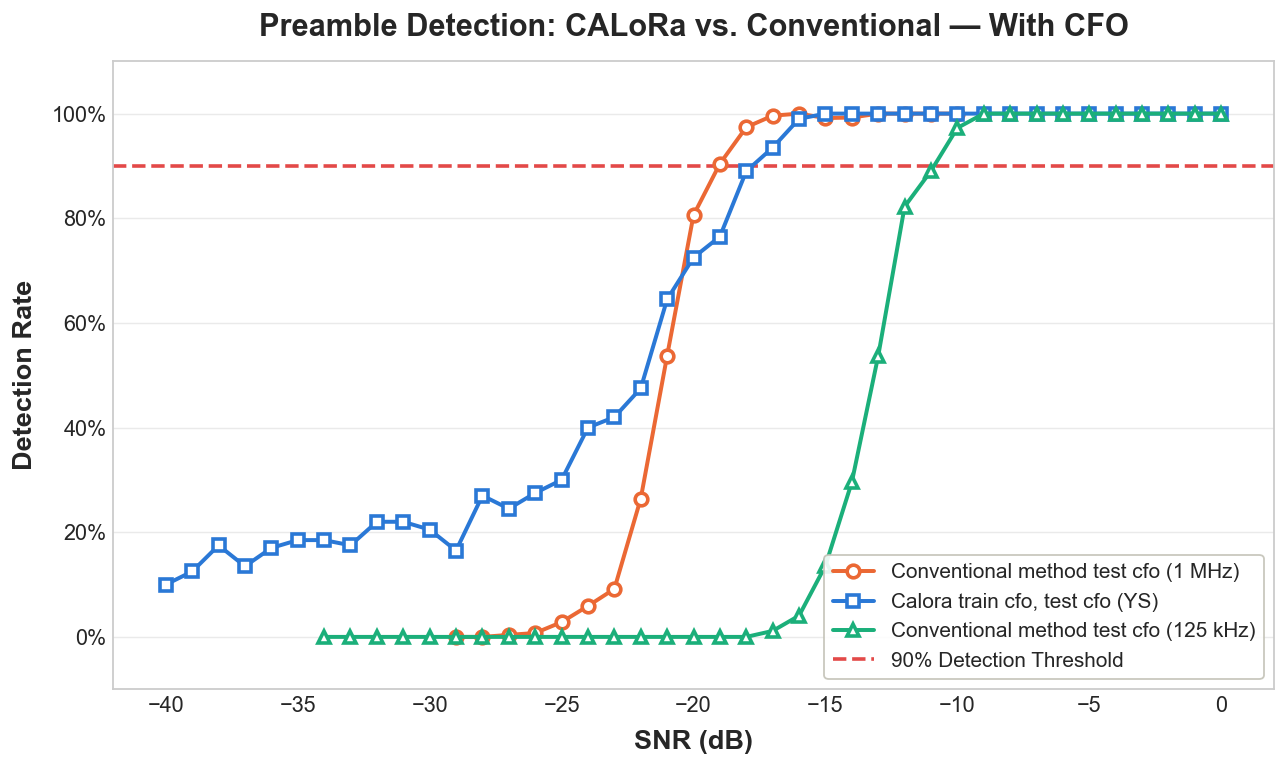


Plot saved to results2/detrate_calora_vs_conventional_cfo.png


In [90]:
# ── Plot all selected files on one graph ─────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')

# Color is assigned by series identity (not list position), so CALoRa and each
# conventional bandwidth keep the same color on every figure in this notebook.
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7']
THRESHOLD_COLOR = '#e34948'

def color_for(lbl, fallback):
    l = lbl.lower()
    if 'calora' in l:
        return PALETTE[0]
    if '1 mhz' in l:
        return PALETTE[1]
    if '125 khz' in l:
        return PALETTE[2]
    return fallback

fig, ax = plt.subplots(figsize=(10, 6), dpi=130)

markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

for i, fname in enumerate(selected_files):
    path = os.path.join(results_dir, fname)
    
    if not os.path.isfile(path):
        continue
    
    df = pd.read_csv(path).reset_index(drop=True)
    df = df.rename(columns={'snr': 'SNR', 'det_rate': 'DetRate'})
    if df['DetRate'].mean() > 1:
    # If yes, divide the entire column by 100 to convert it from percentages to decimals
        df['DetRate'] = df['DetRate'] / 100
    # Use custom label or fallback to filename
    lbl = labels[i] if i < len(labels) and labels[i] else fname.replace('calora_results_', '').replace('.csv', '')
    color = color_for(lbl, PALETTE[i % len(PALETTE)])
    
    ax.plot(
        df['SNR'], df['DetRate'],
        marker=markers[i % len(markers)],
        markersize=7, linewidth=2.2,
        color=color,
        markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=color,
        label=lbl
    )

# Reference line: 90% detection rate threshold
ax.axhline(y=0.9, color=THRESHOLD_COLOR, linestyle='--', linewidth=2, zorder=1,
           label='90% Detection Threshold')

ax.set_xlabel('SNR (dB)', fontsize=15, fontweight='bold', labelpad=8)
ax.set_ylabel('Detection Rate', fontsize=15, fontweight='bold', labelpad=8)
ax.set_title('Preamble Detection: CALoRa vs. Conventional — With CFO', fontsize=17, fontweight='bold', pad=14)
ax.set_ylim(-0.1, 1.10)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=11.5, loc='lower right', frameon=True, framealpha=0.9, edgecolor='#c3c2b7')
ax.grid(True, axis='y', alpha=0.4)
ax.grid(False, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'detrate_calora_vs_conventional_cfo.png'), dpi=200, bbox_inches='tight')
plt.show()
print('\nPlot saved to results2/detrate_calora_vs_conventional_cfo.png')